# Stabilitet

For å forstå stabilitet i dynamiske kraftnett må vi definere tidsaspektet. Hittil har vi jobbet med tiddserier og tidsserieanalyse, for å modellere kraftnettet. Vi skal nå bevege oss inn på transient-, spenning- og frekvensstabilitet.

Vi starter med den generiske sinusoide funksjonen og husker Eulers formel: $e^{j\theta}=cos\theta+jsin\theta$.

I denne boken bruker vi MKS-enheter og IEEE-standarder så langt det lar seg gjøre
Meter–Kilogram–Sekund (MKS) systemet er et enhetssystem der de grunnleggende måleenhetene er:

Lengde: meter (m)

Masse: kilogram (kg)

Tid: sekund (s)

MKS betyr at vi bygger alle fysiske størrelser fra meter, kilogram og sekund – og det er grunnlaget for SI-enhetene vi bruker i kraftsystemer.

$$ 1 V = \frac{kg\cdot m^2}{s^3\cdot A} $$

Alle fysiske størrelser i kraftsystemer er egentlig i SI-enheter (MKS-basert):

Spenning: Volt
Strøm: Ampere
Effekt: Watt
Impedans: Ohm

Per enhet normaliserer MKS-verdier ved å dividere med en valgt baseverdi, for å skape dimensjonsløse tall uten enheter

$$ x_{pu} = \frac{x_{MKS}}{x_{base}} $$

### Baser

Fra basene $S_{base}(VA)$ og $V_{base}(Volt)$ kan vi utlede:
$$I_{base} = \frac{S_{base}}{\sqrt{3}V_{base}}$$
$$Z_{base} = \frac{V^2_{base}}{S_{base}}$$

### Tidsdomene og fasor

Tidsdomenerepresentasjon for spenning kan beskrives som: $v(t)=\hat{V} \cdot cos(\omega t)$

Små bokstaver (v) brukes til å representere instansverdier som varierer som funksjon av tiden (t).

Mens stor bokstav (V) er konstant.

Representasjon av tiden og konstanter er ikke standardisert som ved (MKS, SI og IEEE), men et produkt av konvensjoner; hva man over tid har blitt enige om å uttrykke noe på. Dette er også en god beskrivelse av forskjellen på standarder og konvensjoner.

Der $\hat{V}$ er spenningens amplitude, frekvensen (f) er 50 Hz (50 svingninger i sekundet).

I python-scriptet under er V_ampl den konstante spenningen mens v forandrer seg med tid (t)

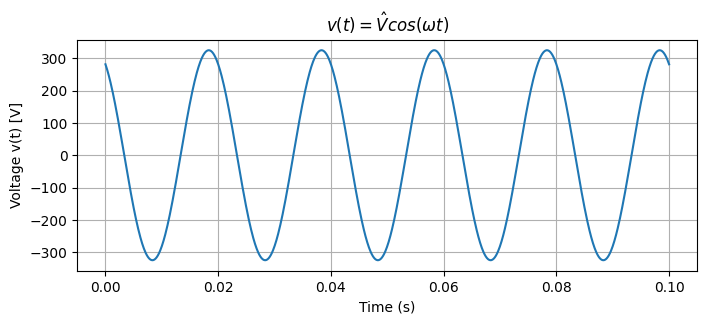

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
V_ampl = 325            # Peak voltage [V]
f = 50                 # Frequency [Hz]
omega = 2*np.pi*f      # Angular frequency
theta_v = np.pi/6     # Phase angle (30 degrees)

# Time vector
t = np.linspace(0, 0.1, 1000)

# Voltage signal
v = V_ampl * np.cos(omega * t + theta_v)

# Plot
plt.figure(figsize=(8, 3))
plt.plot(t, v)
plt.xlabel("Time (s)")
plt.ylabel("Voltage v(t) [V]")
plt.title(r"$v(t) = \hat{V} cos(ωt)$")
plt.grid()
plt.show()

I kraftsystemer beskriver man ofte cos($\omega t$), fordi dette viser projeksjonen av spenningen v, i cosinusplanet og gir verdien 1 der v(t) = 0. Da er v(0) lik V den konstante, som er det samme som amplitudeverdien $\hat{V}$. På denne måten beskriver cosinus systemet ved kontinuerlig drift som et steady-state perspektiv. Steady-state perspektivet er også en viktig faktor når vektoren (V) roterer i tidsdomenet og blir en fasorrepresentasjon.

## Tidsdomene (bølgeform) og roterende vektor (fasor)
Fasorrepresentasjonen blir særlig aktuell ved faseforskyvning, nyttig for å vise faseforskyvning av spenning (som i trefasesystemer) eller strøm (på grunn av passive komponenter:

$$v(t)=\hat{V} \cdot sin(\omega t+ \theta_v) \Longleftrightarrow \bar{V} = \hat{V} \angle \theta$$

![Phasor animation](phasor_animation_sin.gif)

Vi bruker benevnelsen $\bar{V}$ for å vise at det er et kompleks tall med en utstrekning (amplitude - \hat{V}) og fase ($\theta$). Utstrekningen er også magnituden eller absoluttverdien |V|, der fasen eller vinkelen er argumentet til det komplekse tallet.

I kraftsystemer er konvensjonen å jobbe med cosinusrepresentasjon på grunn av steady-state perspektivet nevnt ovenfor.

![Phasor animation](phasor_animation_fixed.gif)



$$
\Re\{e^{j\omega t}\} = \cos(\omega t)
$$


- ingen ekstra fase  
- fasoren peker langs x-aksen ved $t = 0$



$$
\Im\{e^{j\omega t}\} = \sin(\omega t)
$$

👉 Men da skjer dette:

- ved $t = 0$: verdi = 0  
- du "ser" ikke vektoren direkte  

Når du bruker realdelen:

$$
v(t) = \Re\{V e^{j\omega t}\}
$$

blir koblingen:

$$
V = |V| e^{j\theta}
$$

helt direkte.


### Resultat:

$$
v(t) = |V| \cos(\omega t + \theta)
$$

- fasen $\theta$ er akkurat den samme som i fasoren  
- ingen ekstra forskyvning  

Med sinus må du skrive:

$$
v(t) = |V| \sin(\omega t + \theta)
$$

som egentlig er:

$$
= |V| \cos(\omega t + \theta - 90^\circ)
$$

altså:

$$
V = |V| e^{j(\theta - 90^\circ)}
$$

![Phasor animation](complex_exponential.gif)

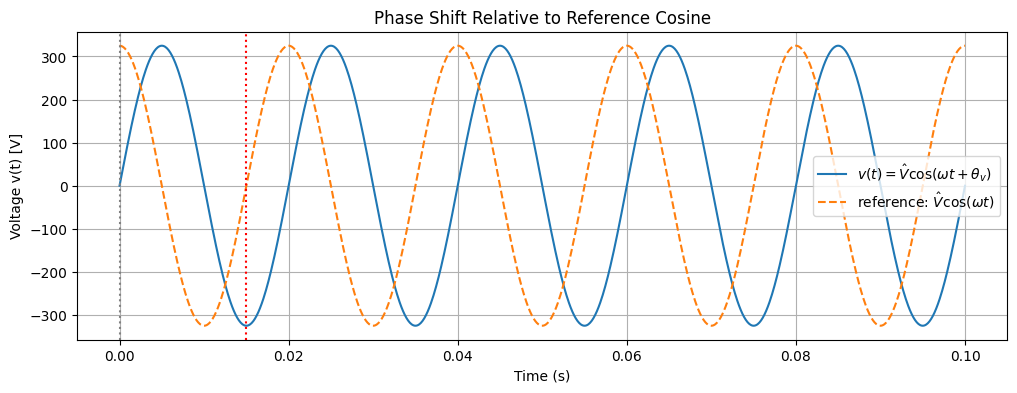

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
V_hat = 325                 # Peak voltage [V]
f = 50                      # Frequency [Hz]
omega = 2 * np.pi * f       # Angular frequency
theta_v = 3*np.pi/2     # Phase angle (30 degrees)

# Time vector
t = np.linspace(0, 0.1, 1000)

# Signals
v_shifted = V_hat * np.cos(omega * t + theta_v)
v_ref = V_hat * np.cos(omega * t)   # reference (no phase shift)

T = 1/f
time_shift = theta_v / omega  # left shift
# Plot
plt.figure(figsize=(12, 4))

plt.plot(t, v_shifted, label=r"$v(t)=\hat{V}\cos(\omega t + \theta_v)$")
plt.plot(t, v_ref, "--", label=r"reference: $\hat{V}\cos(\omega t)$")
plt.axvline(0, color='gray', linestyle=':')
plt.axvline(time_shift, color='red', linestyle=':')
plt.xlabel("Time (s)")
plt.ylabel("Voltage v(t) [V]")
plt.title(r"Phase Shift Relative to Reference Cosine")

plt.legend()
plt.grid()

plt.show()

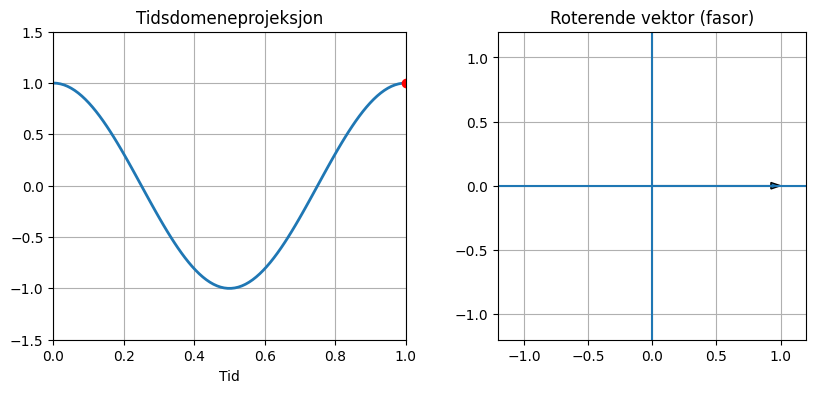

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
V = 1.0
omega = 2 * np.pi  # 1 Hz
theta = 0

# Time points
frames = 100
t_vals = np.linspace(0, 1, frames)

# Precompute full cosine
v_vals = V * np.cos(omega * t_vals + theta)

# Prepare figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left plot (waveform)
ax1.set_xlim(0, 1)
ax1.set_ylim(-1.5, 1.5)
ax1.set_title("Tidsdomeneprojeksjon")
ax1.set_xlabel("Tid")
ax1.grid()

line, = ax1.plot([], [], lw=2)
point, = ax1.plot([], [], 'ro')

# Right plot (phasor)
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_aspect('equal')
ax2.set_title("Roterende vektor (fasor)")
ax2.grid()

# Animation function
def animate(i):
    t = t_vals[i]
    angle = omega * t + theta

    # Phasor components
    x = V * np.cos(angle)
    y = V * np.sin(angle)

    # Redraw phasor axis cleanly
    ax2.clear()
    ax2.set_xlim(-1.2, 1.2)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_aspect('equal')
    ax2.set_title("Roterende vektor (fasor)")
    ax2.grid()
    ax2.axhline(0)
    ax2.axvline(0)
    ax2.arrow(0, 0, x, y, head_width=0.05, length_includes_head=True)

    # Update waveform (NO append)
    line.set_data(t_vals[:i+1], v_vals[:i+1])
    point.set_data([t], [v_vals[i]])

    return line, point

# Use blitting for stability
ani = animation.FuncAnimation(
    fig, animate, frames=frames, interval=50, blit=True
)

# Display in notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

# Save GIF
ani.save("phasor_animation_fixed.gif", writer='pillow', fps=20)

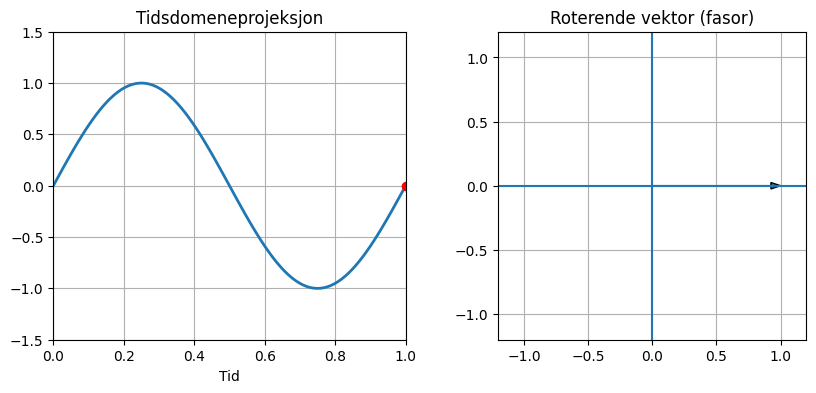

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parameters
V = 1.0
omega = 2 * np.pi  # 1 Hz
theta = 0

# Time points
frames = 100
t_vals = np.linspace(0, 1, frames)

# Precompute full cosine
v_vals = V * np.sin(omega * t_vals + theta)

# Prepare figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Left plot (waveform)
ax1.set_xlim(0, 1)
ax1.set_ylim(-1.5, 1.5)
ax1.set_title("Tidsdomeneprojeksjon")
ax1.set_xlabel("Tid")
ax1.grid()

line, = ax1.plot([], [], lw=2)
point, = ax1.plot([], [], 'ro')

# Right plot (phasor)
ax2.set_xlim(-1.2, 1.2)
ax2.set_ylim(-1.2, 1.2)
ax2.set_aspect('equal')
ax2.set_title("Roterende vektor (fasor)")
ax2.grid()

# Animation function
def animate(i):
    t = t_vals[i]
    angle = omega * t + theta

    # Phasor components
    x = V * np.cos(angle)
    y = V * np.sin(angle)

    # Redraw phasor axis cleanly
    ax2.clear()
    ax2.set_xlim(-1.2, 1.2)
    ax2.set_ylim(-1.2, 1.2)
    ax2.set_aspect('equal')
    ax2.set_title("Roterende vektor (fasor)")
    ax2.grid()
    ax2.axhline(0)
    ax2.axvline(0)
    ax2.arrow(0, 0, x, y, head_width=0.05, length_includes_head=True)

    # Update waveform (NO append)
    line.set_data(t_vals[:i+1], v_vals[:i+1])
    point.set_data([t], [v_vals[i]])

    return line, point

# Use blitting for stability
ani = animation.FuncAnimation(
    fig, animate, frames=frames, interval=50, blit=True
)

# Display in notebook
from IPython.display import HTML
HTML(ani.to_jshtml())

# Save GIF
ani.save("phasor_animation_sin.gif", writer='pillow', fps=20)

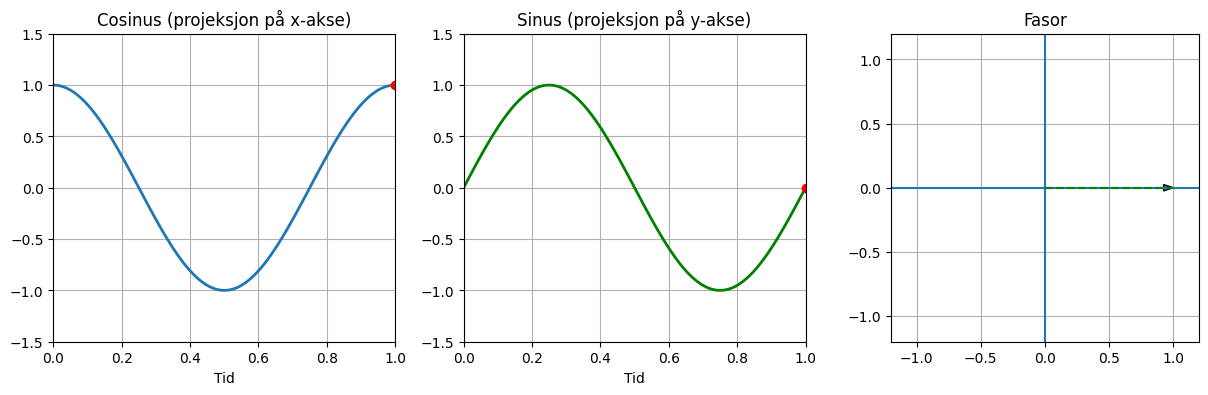

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parametere
V = 1.0
omega = 2 * np.pi
theta = 0

frames = 100
t_vals = np.linspace(0, 1, frames)

# Precompute
cos_vals = V * np.cos(omega * t_vals + theta)
sin_vals = V * np.sin(omega * t_vals + theta)

# Figur: tre plott
fig, (ax_cos, ax_sin, ax_phase) = plt.subplots(1, 3, figsize=(15, 4))

# --- COSINUS ---
ax_cos.set_xlim(0, 1)
ax_cos.set_ylim(-1.5, 1.5)
ax_cos.set_title("Cosinus (projeksjon på x-akse)")
ax_cos.set_xlabel("Tid")
ax_cos.grid()

line_cos, = ax_cos.plot([], [], lw=2)
point_cos, = ax_cos.plot([], [], 'ro')

# --- SINUS ---
ax_sin.set_xlim(0, 1)
ax_sin.set_ylim(-1.5, 1.5)
ax_sin.set_title("Sinus (projeksjon på y-akse)")
ax_sin.set_xlabel("Tid")
ax_sin.grid()

line_sin, = ax_sin.plot([], [], lw=2, color='green')
point_sin, = ax_sin.plot([], [], 'ro')

# --- FASOR ---
ax_phase.set_xlim(-1.2, 1.2)
ax_phase.set_ylim(-1.2, 1.2)
ax_phase.set_aspect('equal')
ax_phase.set_title("Fasor")
ax_phase.grid()

# Animation
def animate(i):
    t = t_vals[i]
    angle = omega * t + theta

    x = V * np.cos(angle)
    y = V * np.sin(angle)

    # Tegn fasor
    ax_phase.clear()
    ax_phase.set_xlim(-1.2, 1.2)
    ax_phase.set_ylim(-1.2, 1.2)
    ax_phase.set_aspect('equal')
    ax_phase.set_title("Fasor")
    ax_phase.grid()
    ax_phase.axhline(0)
    ax_phase.axvline(0)

    # pil
    ax_phase.arrow(0, 0, x, y, head_width=0.05, length_includes_head=True)

    # projeksjonslinjer (veldig pedagogisk!)
    ax_phase.plot([x, x], [0, y], 'r--')  # ned til x-akse
    ax_phase.plot([0, x], [y, y], 'g--')  # bort til y-akse

    # Oppdater cosinus (x)
    line_cos.set_data(t_vals[:i+1], cos_vals[:i+1])
    point_cos.set_data([t], [cos_vals[i]])

    # Oppdater sinus (y)
    line_sin.set_data(t_vals[:i+1], sin_vals[:i+1])
    point_sin.set_data([t], [sin_vals[i]])

    return line_cos, point_cos, line_sin, point_sin

ani = animation.FuncAnimation(
    fig, animate, frames=frames, interval=50, blit=True
)

from IPython.display import HTML
HTML(ani.to_jshtml())

ani.save("cos_vs_sin.gif", writer='pillow', fps=20)

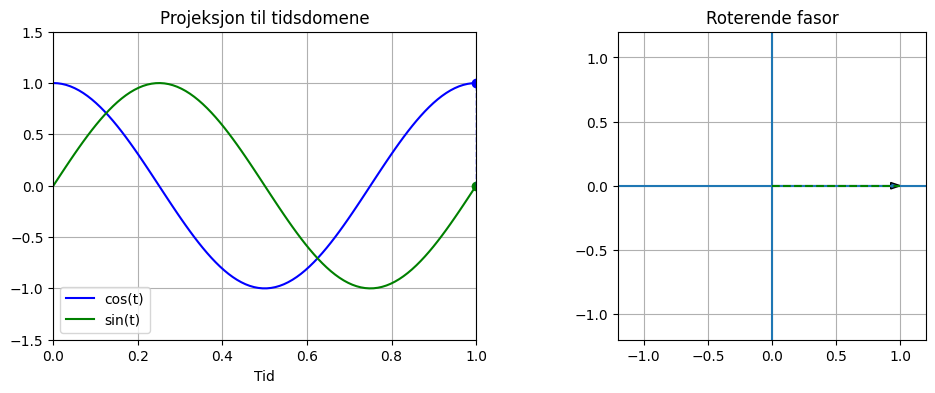

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parametere
V = 1.0
omega = 2 * np.pi
theta = 0

frames = 100
t_vals = np.linspace(0, 1, frames)

# Precompute
cos_vals = V * np.cos(omega * t_vals + theta)
sin_vals = V * np.sin(omega * t_vals + theta)

# Figur
fig, (ax_wave, ax_phase) = plt.subplots(1, 2, figsize=(12, 4))

# --- TIDSPLOTT ---
ax_wave.set_xlim(0, 1)
ax_wave.set_ylim(-1.5, 1.5)
ax_wave.set_title("Projeksjon til tidsdomene")
ax_wave.set_xlabel("Tid")
ax_wave.grid()

line_cos, = ax_wave.plot([], [], label="cos(t)", color='blue')
line_sin, = ax_wave.plot([], [], label="sin(t)", color='green')

point_cos, = ax_wave.plot([], [], 'bo')
point_sin, = ax_wave.plot([], [], 'go')

# projeksjonslinje i tidsplottet
proj_line_cos, = ax_wave.plot([], [], 'b--', lw=1)
proj_line_sin, = ax_wave.plot([], [], 'g--', lw=1)

ax_wave.legend()

# --- FASOR ---
ax_phase.set_xlim(-1.2, 1.2)
ax_phase.set_ylim(-1.2, 1.2)
ax_phase.set_aspect('equal')
ax_phase.set_title("Roterende fasor")
ax_phase.grid()

def animate(i):
    t = t_vals[i]
    angle = omega * t + theta

    x = V * np.cos(angle)
    y = V * np.sin(angle)

    # --- FASOR ---
    ax_phase.clear()
    ax_phase.set_xlim(-1.2, 1.2)
    ax_phase.set_ylim(-1.2, 1.2)
    ax_phase.set_aspect('equal')
    ax_phase.set_title("Roterende fasor")
    ax_phase.grid()
    ax_phase.axhline(0)
    ax_phase.axvline(0)

    # pil
    ax_phase.arrow(0, 0, x, y, head_width=0.05, length_includes_head=True)

    # projeksjoner i faseplanet
    ax_phase.plot([x, x], [0, y], 'b--')  # cos (x)
    ax_phase.plot([0, x], [y, y], 'g--')  # sin (y)

    # --- TIDSPLOTT ---
    line_cos.set_data(t_vals[:i+1], cos_vals[:i+1])
    line_sin.set_data(t_vals[:i+1], sin_vals[:i+1])

    point_cos.set_data([t], [cos_vals[i]])
    point_sin.set_data([t], [sin_vals[i]])

    # KOBLINGEN:
    # horisontal "overføring" fra nåværende tidspunkt
    proj_line_cos.set_data([t, t], [0, cos_vals[i]])
    proj_line_sin.set_data([t, t], [0, sin_vals[i]])

    return (
        line_cos, line_sin,
        point_cos, point_sin,
        proj_line_cos, proj_line_sin
    )

ani = animation.FuncAnimation(
    fig, animate, frames=frames, interval=50, blit=True
)

from IPython.display import HTML
HTML(ani.to_jshtml())

ani.save("phasor_projection_lines.gif", writer='pillow', fps=20)

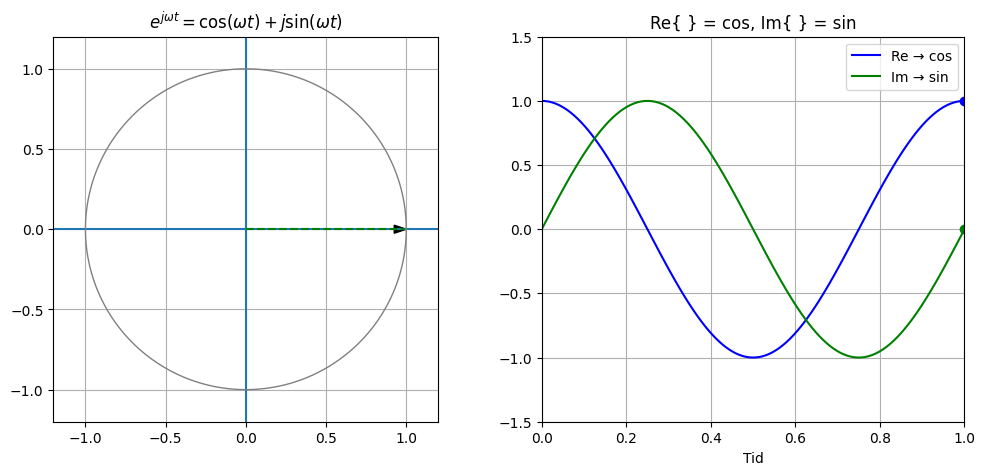

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# Parametere
V = 1.0
omega = 2 * np.pi
theta = 0

frames = 120
t_vals = np.linspace(0, 1, frames)

# Kompleks eksponential
z_vals = V * np.exp(1j * (omega * t_vals + theta))

# Re og Im
cos_vals = np.real(z_vals)
sin_vals = np.imag(z_vals)

# Figur
fig, (ax_complex, ax_time) = plt.subplots(1, 2, figsize=(12, 5))

# --- KOMPLEKSPLAN ---
ax_complex.set_xlim(-1.2, 1.2)
ax_complex.set_ylim(-1.2, 1.2)
ax_complex.set_aspect('equal')
ax_complex.set_title("Kompleks plan: $e^{j\\omega t}$")
ax_complex.grid()

# --- TIDSPLOTT ---
ax_time.set_xlim(0, 1)
ax_time.set_ylim(-1.5, 1.5)
ax_time.set_title("Re{ } = cos, Im{ } = sin")
ax_time.set_xlabel("Tid")
ax_time.grid()

line_cos, = ax_time.plot([], [], label="Re → cos", color='blue')
line_sin, = ax_time.plot([], [], label="Im → sin", color='green')

point_cos, = ax_time.plot([], [], 'bo')
point_sin, = ax_time.plot([], [], 'go')

ax_time.legend()

def animate(i):
    t = t_vals[i]
    z = z_vals[i]

    x = np.real(z)
    y = np.imag(z)

    # --- KOMPLEKSPLAN ---
    ax_complex.clear()
    ax_complex.set_xlim(-1.2, 1.2)
    ax_complex.set_ylim(-1.2, 1.2)
    ax_complex.set_aspect('equal')
    ax_complex.set_title(r"$e^{j\omega t} = \cos(\omega t) + j\sin(\omega t)$")
    ax_complex.grid()

    ax_complex.axhline(0)
    ax_complex.axvline(0)

    # Vektor = e^{jωt}
    ax_complex.arrow(0, 0, x, y,
                     head_width=0.05,
                     length_includes_head=True,
                     color='black')

    # Projeksjoner
    ax_complex.plot([x, x], [0, y], 'b--', label="Re")
    ax_complex.plot([0, x], [y, y], 'g--', label="Im")

    # Sirkel (unit circle)
    theta_circle = np.linspace(0, 2*np.pi, 200)
    ax_complex.plot(np.cos(theta_circle), np.sin(theta_circle), 'gray', lw=1)

    # --- TIDSPLOTT ---
    line_cos.set_data(t_vals[:i+1], cos_vals[:i+1])
    line_sin.set_data(t_vals[:i+1], sin_vals[:i+1])

    point_cos.set_data([t], [cos_vals[i]])
    point_sin.set_data([t], [sin_vals[i]])

    return line_cos, line_sin, point_cos, point_sin

ani = animation.FuncAnimation(
    fig, animate, frames=frames, interval=50, blit=True
)

from IPython.display import HTML
HTML(ani.to_jshtml())

ani.save("complex_exponential.gif", writer='pillow', fps=20)


# 📘 Notation Cheat Sheet (Power Systems & RMS Simulation)

---

## 🔹 1. Time-domain (instantaneous signal)


$$ v(t) = \sqrt{2} V \cos(\omega t + \theta) $$


- \( v(t) \): instantaneous voltage  
- \( V \): **RMS value**  
- \( \sqrt{2}V \): peak value  
- \( \omega = 2\pi f \): angular frequency  
- \( \theta \): phase angle  

👉 Real waveform in time (EMT view)

---

## 🔹 2. Phasor (IEEE notation)

$$\bar{V} = V \angle \theta$$

or

$$
\bar{V} = V e^{j\theta}
$$

- \( V \): RMS magnitude  
- \( \theta \): phase  
- \( j = \sqrt{-1} \)

👉 Compact representation of sinusoid  
👉 No explicit time dependence  

---

## 🔹 3. Link: Time-domain → Phasor

$$v(t) = \sqrt{2} \, \Re \left\{ \underline{V} e^{j\omega t} \right\}$$


👉 Phasor rotates at frequency \( \omega \)  
👉 RMS simulation tracks \( \underline{V}(t) \)

---

## 🔹 4. Rectangular form

\[
\underline{V} = V_d + j V_q = V(\cos\theta + j\sin\theta)
\]

- Real part = in-phase component  
- Imaginary part = quadrature component  

---

## 🔹 5. Current and impedance

\[
\underline{I} = I \angle \theta_i
\]

\[
\underline{Z} = R + jX
\]

Ohm’s law (phasor form):

\[
\underline{V} = \underline{Z} \cdot \underline{I}
\]

---

## 🔹 6. Complex power

\[
\underline{S} = \underline{V} \cdot \underline{I}^*
= P + jQ
\]

- \( P \): active power (W)  
- \( Q \): reactive power (var)  

---

## 🔹 7. Per unit system

\[
x_{pu} = \frac{x}{x_{base}}
\]

- Removes units  
- Keeps physical relationships  

---

## 🔹 8. RMS vs EMT interpretation

### RMS:
\[
\underline{V}(t) = V(t)\angle\theta(t)
\]

👉 Simulates phasors (magnitude + phase)

### EMT:
\[
v(t)
\]

👉 Simulates instantaneous waveform

---

# 🎯 Key takeaway

**Time-domain signals are sinusoidal, but RMS simulation tracks only their phasors (RMS magnitude + phase).**
``